# Handling Outliers


---
### Author :  Muhammad Ali Saagar

**Python Developer • Data Science • AI/ML Engineer**

#### 🔗 Connect With Me

[![GitHub](https://img.shields.io/badge/GitHub-Profile-181717?style=for-the-badge\&logo=github)](https://github.com/AliMuhammad78)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Profile-0A66C2?style=for-the-badge\&logo=linkedin)](https://www.linkedin.com/in/muhammad-ali-91294a290)
[![Kaggle](https://img.shields.io/badge/Kaggle-Profile-20BEFF?style=for-the-badge\&logo=kaggle)](https://www.kaggle.com/ali98muhammad45)
[![YouTube](https://img.shields.io/badge/YouTube-Channel-FF0000?style=for-the-badge\&logo=youtube)](https://www.youtube.com/@TechyBits20121)
[![Email](https://img.shields.io/badge/Email-Contact-D14836?style=for-the-badge\&logo=gmail)](mailto:alisaagar86@gmail.com)

---

### Acknowledgement

> Most of the examples in this notebook are based on the excellent tutorials by **Dr. Muhammad Aammar Tufail (Codanics)**. I sincerely thank him for sharing his knowledge and practical examples.

 [![GitHub](https://img.shields.io/badge/GitHub-Profile-181717?style=for-the-badge\&logo=github)](https://github.com/AammarTufail)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Profile-0A66C2?style=for-the-badge\&logo=linkedin)](https://www.linkedin.com/in/dr-muhammad-aammar-tufail-02471213b/)
[![Kaggle](https://img.shields.io/badge/Kaggle-Profile-20BEFF?style=for-the-badge\&logo=kaggle)](https://www.kaggle.com/muhammadaammartufail)
[![YouTube](https://img.shields.io/badge/YouTube-Channel-FF0000?style=for-the-badge\&logo=youtube)](https://www.youtube.com/@codanics)

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 


In [3]:
data= pd.DataFrame({ "Age" : [22, 25,12 , 24 , 32, 27, 30,29 , 95, 1600] })
data

,Age
0,22
1,25
2,12
3,24
4,32
5,27
6,30
7,29
8,95
9,1600


<Axes: xlabel='Age', ylabel='Count'>

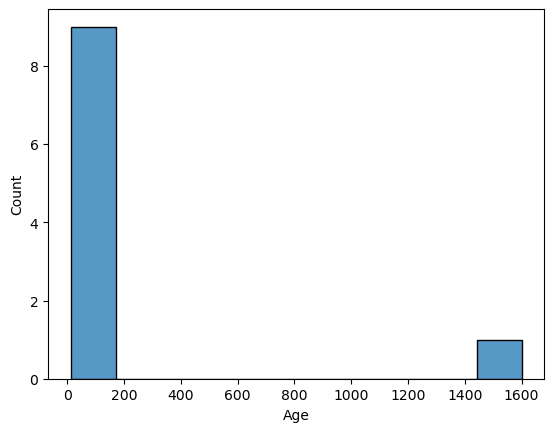

In [4]:
sns.histplot(data["Age"], bins=10)

<Axes: >

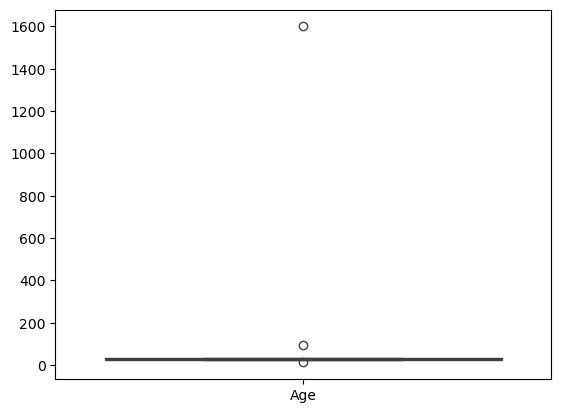

In [5]:
sns.boxplot(data=data)

## By Z-score 

In [7]:
mean = data["Age"].mean()
std = data["Age"].std()
data["mean"] = data["Age"].mean()
data["std" ]= data["Age"].std()

data["Z-score"] = (data["Age" ]- mean )/std
data


,Age,mean,std,Z-score
0,22,189.6,496.080907,-0.337848
1,25,189.6,496.080907,-0.331801
2,12,189.6,496.080907,-0.358006
3,24,189.6,496.080907,-0.333817
4,32,189.6,496.080907,-0.317690
5,27,189.6,496.080907,-0.327769
6,30,189.6,496.080907,-0.321722
7,29,189.6,496.080907,-0.323738
8,95,189.6,496.080907,-0.190695
9,1600,189.6,496.080907,2.843085


Seeing outliers

In [8]:
print("The outliers in the data are\n" , data[data["Z-score"] > 3])

The outliers in the data are
 Empty DataFrame
Columns: [Age, mean, std, Z-score]
Index: []


### Remove the outliers


In [9]:
data = data[data["Z-score"].abs() <= 3]
data

,Age,mean,std,Z-score
0,22,189.6,496.080907,-0.337848
1,25,189.6,496.080907,-0.331801
2,12,189.6,496.080907,-0.358006
3,24,189.6,496.080907,-0.333817
4,32,189.6,496.080907,-0.317690
5,27,189.6,496.080907,-0.327769
6,30,189.6,496.080907,-0.321722
7,29,189.6,496.080907,-0.323738
8,95,189.6,496.080907,-0.190695
9,1600,189.6,496.080907,2.843085


In [10]:
from scipy import stats

data = np.array([22, 25,12 , 24 , 32, 27, 30,29 , 95, 1600])
z_score = stats.zscore(data)
threshold = 2.5
print("The outliers in the data are\n" , data[np.abs(z_score) > threshold]) 

data = data[np.abs(z_score) <= threshold]
print("The data after removing the outliers is\n" , data)

The outliers in the data are
 [1600]
The data after removing the outliers is
 [22 25 12 24 32 27 30 29 95]


## Using InterQuartile Range

In [11]:
data = pd.DataFrame({ "Age" : [22, 25,12 , 24 , 32, 27, 30,29 , 95, 1600] })
Q1 = np.percentile(data["Age"], 25 , interpolation = "midpoint")
Q3 = np.percentile(data["Age"], 75, interpolation = "midpoint")
# Q1 = data["Age"].quantile(0.25)
# Q3 = data["Age"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = data[(data["Age"] < lower_bound) | (data["Age"] > upper_bound)]
print("The data without outliers is \n " , data)
print("The outliers in the data are\n" , outliers )


# Remove the outliers 
data = data[(data["Age"] >= lower_bound) & (data["Age"] <= upper_bound)]
print("The data after removing the outliers is\n" , data)

The data without outliers is 
      Age
0    22
1    25
2    12
3    24
4    32
5    27
6    30
7    29
8    95
9  1600
The outliers in the data are
     Age
2    12
8    95
9  1600
The data after removing the outliers is
    Age
0   22
1   25
3   24
4   32
5   27
6   30
7   29


### By using K-mean clustring  algorithm 
- Form clusters using K-Means Clustering

- Calculate distance of each point from its cluster center

- Points very far from center → outliers → remov

Cluster Centers:
 [[ 5.  5.]
 [20. 20.]]
Cluster Labels:
 [0 0 0 0 0 0 1]
Distances from cluster centers:
 [np.float64(5.0), np.float64(5.0), np.float64(4.242640687119285), np.float64(4.242640687119285), np.float64(5.0), np.float64(5.0), np.float64(0.0)]
Data after removing outliers:
 [[20 20]]


c:\Users\UsEr\miniconda3\envs\python_ML\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


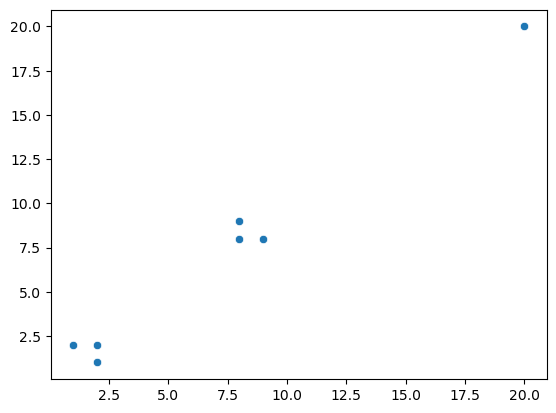

In [12]:
import numpy as np
from sklearn.cluster import KMeans

# Sample data
data = np.array([
    [1,2],
    [2,1],
    [2,2],
    [8,8],
    [9,8],
    [8,9],
    [20,20]
])
sns.scatterplot(x=data[:,0], y=data[:,1])
# Create KMeans model
kmeans = KMeans(n_clusters=2, n_init=10, random_state=0)

# Fit the model to the data
kmeans.fit(data)

labels = kmeans.predict(data)

centers = kmeans.cluster_centers_ 

print("Cluster Centers:\n", centers)
print("Cluster Labels:\n", labels)

distances = []

for i in range (len(data)):
    point = data[i]
    center = centers[labels[i]]
    distance = np.linalg.norm(point - center)
    distances.append(distance)
print("Distances from cluster centers:\n", distances)
threshold = 3
clean_data = []
for i in range (len(data)):
   if distances[i]< threshold:
     clean_data.append(data[i])

clean_data = np.array(clean_data)
print("Data after removing outliers:\n", clean_data)
